In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
import os

# Importamos SOLO TCN
from neuralforecast import NeuralForecast
from neuralforecast.models import TCN
from neuralforecast.losses.pytorch import MSE, MAE

warnings.filterwarnings('ignore')
print("✅ Librerías para TCN cargadas.")

d:\programas\tfm\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 16:17:15,978	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-09 16:17:16,192	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✅ Librerías para TCN cargadas.


In [2]:
filename = "dataset_tfm_56_survivors.csv"

if os.path.exists(filename):
    df = pd.read_csv(filename)
    df['ds'] = pd.to_datetime(df['ds'])

    # Configuración Caso 3
    VAL_YEAR = 2023
    
    # --- FILTRO DE SEGURIDAD ---
    # 335 días = 60 input + 5 horizonte + ~260 validación + margen
    counts = df.groupby('unique_id').size().reset_index(name='n_days')
    valid_ids = counts[counts['n_days'] > 335]['unique_id'].unique()
    
    df = df[df['unique_id'].isin(valid_ids)].copy()
    print(f"✅ Empresas aptas tras filtro: {df['unique_id'].nunique()}")

    # Preprocesamiento
    df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()
    stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
    df = pd.merge(df, stats, on='unique_id', how='left')
    df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

    df_final = df.copy()
    df_final['y_raw'] = df_final['y']
    df_final['y'] = df_final['y_norm']
    df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
    df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

    df_input = df_final.copy()
    
    # Val Size Robusto
    df_2023 = df_input[df_input['ds'].dt.year == VAL_YEAR]
    if len(df_2023) > 0:
        val_size = int(df_2023.groupby('unique_id').size().median())
        print(f"✅ Datos listos. Validación: {val_size} días.")
    else:
        print("❌ ERROR: No hay datos en 2023.")

else:
    print(f"❌ ERROR: No se encuentra el archivo '{filename}'.")

✅ Empresas aptas tras filtro: 56
✅ Datos listos. Validación: 255 días.


In [3]:
def ejecutar_tcn_final(param_grid, df_train, val_size):
    print(f"\n🚀 INICIANDO GRID SEARCH PARA TCN (Caso 3)")
    print(f"   📂 Archivo de salida: grid_search_TCN_case3.csv")
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    HORIZONTE = 5
    INPUT_SIZE_FIJO = 60

    for i, params in enumerate(combinations):
        print(f"   ⚙️ [{i+1}/{len(combinations)}] Probando: {params} ...", end=" ")
        
        try:
            # --- CONFIGURACIÓN DINÁMICA TCN ---
            # TCN define su profundidad mediante 'dilations' (potencias de 2)
            # Si n_layers=2 -> dilations=[1, 2]
            # Si n_layers=4 -> dilations=[1, 2, 4, 8]
            current_dilations = [2**k for k in range(params['n_layers'])]
            
            model = TCN(
                h=HORIZONTE,
                input_size=INPUT_SIZE_FIJO,
                loss=MSE(),
                valid_loss=MAE(),
                max_steps=300,
                scaler_type='identity',
                start_padding_enabled=True, # Seguridad
                
                # PARÁMETROS ESPECÍFICOS TCN
                kernel_size=params['kernel_size'],
                
                # Mapeo Clave: TCN usa 'encoder_hidden_size' para el nº de filtros
                encoder_hidden_size=params['hidden_size'], 
                
                # Profundidad calculada
                dilations=current_dilations,
                
                random_seed=42
            )
            
            nf = NeuralForecast(models=[model], freq='B')
            nf.fit(df=df_train, val_size=val_size)
            
            cutoff_date = f"{VAL_YEAR}-01-01"
            df_history = df_train[df_train['ds'] < cutoff_date].copy()
            forecasts = nf.predict(df=df_history).reset_index()
            
            combined = pd.merge(forecasts, df_train[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')
            col_pred = 'TCN'
            mae = (combined['y'] - combined[col_pred]).abs().mean()
            
            # Robustez
            errors_per_id = combined.groupby('unique_id').apply(
                lambda x: (x['y'] - x[col_pred]).abs().mean()
            ).reset_index(name='MAE_Empresa')
            
            vol_data = []
            for uid in df_history['unique_id'].unique():
                series = df_history[df_history['unique_id']==uid]['y']
                v = series.tail(INPUT_SIZE_FIJO).std() if len(series) >= INPUT_SIZE_FIJO else 0
                vol_data.append({'unique_id': uid, 'Input_Vol': v})
            
            df_vol = pd.DataFrame(vol_data)
            analysis = pd.merge(df_vol, errors_per_id, on='unique_id')
            corr = analysis['Input_Vol'].corr(analysis['MAE_Empresa'])
            
            print(f"✅ MAE: {mae:.5f} | Corr: {corr:.4f}")
            
            res = params.copy()
            res['MAE'] = mae
            res['Correlacion'] = corr
            results.append(res)
            
        except Exception as e:
            print(f"❌ Error: {e}")

    if results:
        df_res = pd.DataFrame(results).sort_values('MAE')
        df_res.to_csv("grid_search_TCN_case3.csv", index=False)
        print(f"\n🏆 GANADOR TCN: MAE {df_res.iloc[0]['MAE']:.5f}")

In [ ]:
grid_tcn_params = {
    'kernel_size': [2, 3, 5],       # Añadido 2 (foco local) y 5 (semana bursátil completa)
    'hidden_size': [64, 128, 256, 512],  # Añadido 256 para probar mayor capacidad de extracción
    'n_layers': [2, 4, 6, 8]           # Añadido 6 capas para ampliar drásticamente el Campo Receptivo
}
print("📋 Parámetros TCN listos (Grid Ampliado).")

📋 Parámetros TCN listos (Grid Ampliado).


In [13]:
ejecutar_tcn_final(grid_tcn_params, df_input, val_size)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                       | Params | Mode  | FLOPs
-------------------------------------------------------------------------------
0 | loss            | MSE                        | 0      | train | 0    
1 | valid_loss      | MAE                        | 0      | train | 0    
2 | padder_train    | ConstantPad1d              | 0      | train | 0    
3 | scaler          | TemporalNorm               | 0      | train | 0    
4 | hist_encoder    | TemporalConvolutionEncoder | 144 K  | train | 0    
5 | context_adapter | Linear                     | 305    | train | 0    
6 | mlp_decoder     | MLP                        | 8.4 K  | train | 0    
-------------------------------------------------------------------------------
152 K     Trainable params
0         Non-trainable params
152 K     Total params
0.612     Total estimated mod


🚀 INICIANDO GRID SEARCH PARA TCN (Caso 3)
   📂 Archivo de salida: grid_search_TCN_case3.csv
Epoch 149: 100%|██████████| 2/2 [00:00<00:00,  3.64it/s, v_num=493, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:00<00:00,  3.63it/s, v_num=493, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

✅ MAE: 0.67608 | Corr: 0.3643
Epoch 149: 100%|██████████| 2/2 [00:01<00:00,  1.28it/s, v_num=495, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:01<00:00,  1.28it/s, v_num=495, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 149.04it/s]
✅ MAE: 0.68019 | Corr: 0.3636

🏆 GANADOR TCN: MAE 0.67608


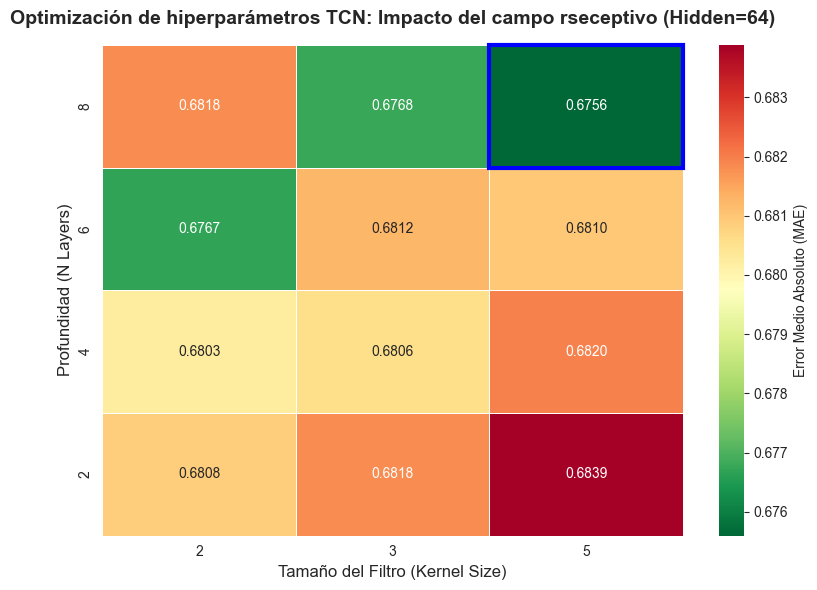

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 1. CARGA DE DATOS
csv_data = """kernel_size,hidden_size,n_layers,MAE,Correlacion
5,64,8,0.675595563605459,0.3644380723672666
2,64,6,0.6766709129726027,0.3639122553603629
3,64,8,0.6767747540156167,0.36396271025505594
5,512,8,0.6769931761044549,0.3640455739436546
3,128,2,0.6777629949015308,0.3639543549115877
2,256,6,0.6785063021920996,0.36972051699531255
2,512,8,0.6788801549397885,0.363713028144897
3,512,4,0.6788916032896051,0.36674179330241924
5,128,6,0.6795205006372127,0.3635440477638272
5,256,8,0.6801666132904642,0.36354825947526836
3,256,8,0.6802414871036391,0.3633341805252294
2,64,4,0.6802582606039729,0.3627798796704786
2,128,6,0.6805182800611537,0.36366813300621187
3,64,4,0.6805787133952441,0.375182612168629
5,256,2,0.68070611892535,0.37036319918849236
2,256,8,0.6808088848077887,0.36362323474816255
2,64,2,0.6808431155039069,0.36186387970137707
2,128,8,0.6808766578036171,0.3633714276853276
2,512,4,0.6809065237888573,0.36478015680783393
2,512,6,0.6809623715245633,0.363078580999556
5,64,6,0.6809636870829975,0.36413521184932446
5,128,4,0.681000631180666,0.36364276818099095
3,64,6,0.6812498276603457,0.3637467421319816
3,512,8,0.6813695621255729,0.3631523800109757
5,128,2,0.6814137664123744,0.37303215221715863
2,256,4,0.6814837644827404,0.36050040147121554
5,256,6,0.6815731876129072,0.3634102443647723
5,128,8,0.6816583732474116,0.36289399336621453
3,512,2,0.6817605423274222,0.3649114904768246
5,512,6,0.6817863174559226,0.3630453617478077
3,64,2,0.6818184783454432,0.36792169631683524
2,64,8,0.6818303554036045,0.36381835212236585
5,64,4,0.681958076680033,0.3687830344966226
2,256,2,0.6821078217143868,0.36732627665634904
3,128,4,0.682226769414944,0.3668804704837737
3,128,6,0.6826449482672642,0.3626775045260262
3,512,6,0.683066185627216,0.36304979193084225
2,128,2,0.6834303732595465,0.3651772441220558
5,512,2,0.6834660755456684,0.37110427045506633
5,64,2,0.6838879387674711,0.36889248537214653
3,256,2,0.6839916610528906,0.3560958227304955
5,256,4,0.6840097447510123,0.3633770954765794
3,128,8,0.684030350294209,0.36327969108282315
5,512,4,0.6844569569825764,0.36477574251828543
3,256,4,0.6845616655272347,0.36355216514906663
3,256,6,0.6846112706536355,0.36253805737298184
2,128,4,0.6848309282100518,0.36133418400727285
2,512,2,0.6859017050990651,0.3588610657736457
"""
df_results = pd.read_csv(StringIO(csv_data))

# 2. PREPARAR DATOS PARA HEATMAP
# Filtramos solo para Hidden=64 (ya que es donde está el ganador)
# para ver la interacción pura entre Kernel y Capas
heatmap_data = df_results[df_results['hidden_size'] == 64].pivot(
    index='n_layers', 
    columns='kernel_size', 
    values='MAE'
)

# 3. GENERAR GRÁFICO ACADÉMICO
plt.figure(figsize=(8, 6))
sns.set_style("white")

# Mapa de Calor con valores
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".4f", 
    cmap="RdYlGn_r", # Rojo es malo (error alto), Verde es bueno (error bajo)
    linewidths=.5,
    cbar_kws={'label': 'Error Medio Absoluto (MAE)'}
)

# 4. PERSONALIZACIÓN
plt.title('Optimización de hiperparámetros TCN: Impacto del campo rseceptivo (Hidden=64)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tamaño del Filtro (Kernel Size)', fontsize=12)
plt.ylabel('Profundidad (N Layers)', fontsize=12)

# Invertir eje Y para que las capas aumenten hacia arriba (más intuitivo)
plt.gca().invert_yaxis()

# Destacar el GANADOR (Caja negra alrededor)
# Coordenadas: Kernel=5 (índice 2), Layers=8 (índice 3) -> Ajustar según los datos
from matplotlib.patches import Rectangle
# Buscamos índices del mínimo
min_val = heatmap_data.min().min()
# Esto es un truco visual, ajusta las coordenadas (x, y) según donde caiga el 0.6756 en tu matriz
# En este caso: Kernel 5 es la columna 2, Layers 8 es la fila 3 (si orden ascendente)
ax.add_patch(Rectangle((2, 3), 1, 1, fill=False, edgecolor='blue', lw=3, clip_on=False))

plt.tight_layout()
plt.savefig('grid_search_tcn_heatmap.png', dpi=300)
plt.show()